In [16]:
import pandas as pd

bikes_path = r"C:\Dublin_Bikes_data\bikes_3months_appended.csv"
bikes = pd.read_csv(bikes_path, low_memory=False)

weather = pd.read_csv("weather_hourly.csv", low_memory=False)

print("Bikes shape:", bikes.shape)
print("Weather shape:", weather.shape)

display(bikes.head())
display(weather.head())


Bikes shape: (1880373, 15)
Weather shape: (2207, 21)


,system_id,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,short_name,address,lat,lon,region_id,capacity
0,dublin_bikes,2025-03-01 00:05:00.000,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),NaN,Grangegorman Lower (Central),53.35517,-6.278424,NaN,40
1,dublin_bikes,2025-03-01 00:15:00.000,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),NaN,Grangegorman Lower (Central),53.35517,-6.278424,NaN,40
2,dublin_bikes,2025-03-01 00:25:00.000,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),NaN,Grangegorman Lower (Central),53.35517,-6.278424,NaN,40
3,dublin_bikes,2025-03-01 00:30:00.000,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),NaN,Grangegorman Lower (Central),53.35517,-6.278424,NaN,40
4,dublin_bikes,2025-03-01 00:35:00.000,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),NaN,Grangegorman Lower (Central),53.35517,-6.278424,NaN,40


,date,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,...,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
0,01-03-2025 01:00,0,0.0,0,4.0,0,2.8,0.9,6.5,80,...,2,4,2,180,2,11,0.0,30000,40,6
1,01-03-2025 02:00,0,0.0,0,4.2,0,2.7,0.3,6.2,75,...,2,4,2,170,2,11,0.0,30000,40,6
2,01-03-2025 03:00,0,0.0,0,4.0,0,2.6,0.3,6.2,77,...,2,4,2,190,2,11,0.0,30000,40,6
3,01-03-2025 04:00,3,0.0,0,2.3,0,1.4,-0.3,6.0,84,...,2,4,2,170,2,11,0.0,30000,999,3
4,01-03-2025 05:00,3,0.0,0,2.8,0,1.8,0.2,6.2,82,...,2,5,2,190,2,11,0.0,30000,999,3


In [17]:
print("Bike columns:")
print(bikes.columns.tolist())

print("\nWeather columns:")
print(weather.columns.tolist())


Bike columns:
['system_id', 'last_reported', 'station_id', 'num_bikes_available', 'num_docks_available', 'is_installed', 'is_renting', 'is_returning', 'name', 'short_name', 'address', 'lat', 'lon', 'region_id', 'capacity']

Weather columns:
['date', 'ind', 'rain', 'ind.1', 'temp', 'ind.2', 'wetb', 'dewpt', 'vappr', 'rhum', 'msl', 'ind.3', 'wdsp', 'ind.4', 'wddir', 'ww', 'w', 'sun', 'vis', 'clht', 'clamt']


In [18]:
bikes.sample(20)

,system_id,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,short_name,address,lat,lon,region_id,capacity
55463,dublin_bikes,2025-03-16 14:30:00.000,5,0,40,True,True,True,CHARLEMONT PLACE,NaN,Charlemont Street,53.330660,-6.260177,NaN,40
1035247,dublin_bikes,2025-04-22 05:40:00.000,91,26,4,True,True,True,SOUTH DOCK ROAD,NaN,South Dock Road,53.341830,-6.231291,NaN,30
1483497,dublin_bikes,2025-04-14 08:10:00.000,29,21,8,True,True,True,ORMOND QUAY UPPER,NaN,Ormond Quay Upper,53.346058,-6.268001,NaN,29
1496314,dublin_bikes,2025-04-19 05:55:00.000,109,17,12,True,True,True,BUCKINGHAM STREET LOWER,NaN,Buckingham Street Lower,53.353333,-6.249319,NaN,29
1333290,dublin_bikes,2025-03-10 14:55:00.000,27,17,3,True,True,True,MOLESWORTH STREET,NaN,Molesworth Street,53.341290,-6.258117,NaN,20
1546809,dublin_bikes,2025-03-12 11:15:00.000,87,7,31,True,True,True,COLLINS BARRACKS MUSEUM,NaN,Collins Barracks Museum,53.347477,-6.285250,NaN,38
1763863,dublin_bikes,2025-05-03 06:10:00.000,79,1,26,True,True,True,ECCLES STREET EAST,NaN,Eccles Street East,53.358116,-6.265601,NaN,27
1459757,dublin_bikes,2025-05-02 20:45:00.000,77,21,8,True,True,True,WOLFE TONE STREET,NaN,Wolfe Tone Street,53.348873,-6.267459,NaN,29
616456,dublin_bikes,2025-04-10 01:05:00.000,97,36,4,True,True,True,KILMAINHAM GAOL,NaN,Kilmainham Gaol,53.342113,-6.310015,NaN,40
1310231,dublin_bikes,2025-03-10 05:05:00.000,17,12,8,True,True,True,GOLDEN LANE,NaN,Golden Lane,53.340800,-6.267732,NaN,20


In [19]:
# CLEANING THE BIKES DATA 

import pandas as pd

print("Starting shape:", bikes.shape)

bikes['last_reported'] = pd.to_datetime(bikes['last_reported'], errors='coerce')

bikes = bikes.dropna(subset=['last_reported', 'station_id'])

for col in ['num_bikes_available', 'num_docks_available', 'capacity']:
    bikes[col] = pd.to_numeric(bikes[col], errors='coerce')

bikes = bikes[bikes['capacity'].notna()]

bikes = bikes[
    (bikes['num_bikes_available'] >= 0) &
    (bikes['num_docks_available'] >= 0)
]

drop_cols = ['region_id', 'short_name']
bikes = bikes.drop(columns=drop_cols, errors='ignore')

bikes = bikes.drop_duplicates()

print("Cleaned shape:", bikes.shape)
print("Date range:", bikes['last_reported'].min(), "→", bikes['last_reported'].max())

bikes.head()

Starting shape: (1880373, 15)
Cleaned shape: (1880373, 13)
Date range: 2025-03-01 00:05:00 → 2025-05-31 23:55:00


,system_id,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,address,lat,lon,capacity
0,dublin_bikes,2025-03-01 00:05:00,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),Grangegorman Lower (Central),53.35517,-6.278424,40
1,dublin_bikes,2025-03-01 00:15:00,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),Grangegorman Lower (Central),53.35517,-6.278424,40
2,dublin_bikes,2025-03-01 00:25:00,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),Grangegorman Lower (Central),53.35517,-6.278424,40
3,dublin_bikes,2025-03-01 00:30:00,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),Grangegorman Lower (Central),53.35517,-6.278424,40
4,dublin_bikes,2025-03-01 00:35:00,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),Grangegorman Lower (Central),53.35517,-6.278424,40


In [20]:
# CLEANING THE WEATHER DATA

print("Starting weather shape:", weather.shape)

weather['datetime'] = pd.to_datetime(weather['date'], dayfirst=True, errors='coerce')

weather = weather.dropna(subset=['datetime'])

start = bikes['last_reported'].min().floor('h')
end   = bikes['last_reported'].max().ceil('h')
weather = weather[(weather['datetime'] >= start) & (weather['datetime'] <= end)].copy()

weather = weather[['datetime', 'rain', 'temp', 'wdsp', 'rhum']].copy()

for col in ['rain', 'temp', 'wdsp', 'rhum']:
    weather[col] = pd.to_numeric(weather[col], errors='coerce')

weather = weather.drop_duplicates()

print("Cleaned weather shape:", weather.shape)
print("Weather time range:", weather['datetime'].min(), "→", weather['datetime'].max())

weather.head()


Starting weather shape: (2207, 21)
Cleaned weather shape: (2207, 5)
Weather time range: 2025-03-01 01:00:00 → 2025-05-31 23:00:00


,datetime,rain,temp,wdsp,rhum
0,2025-03-01 01:00:00,0.0,4.0,4,80
1,2025-03-01 02:00:00,0.0,4.2,4,75
2,2025-03-01 03:00:00,0.0,4.0,4,77
3,2025-03-01 04:00:00,0.0,2.3,4,84
4,2025-03-01 05:00:00,0.0,2.8,5,82


In [21]:
# BASIC DERIVED COLUMNS FOR BIKES

bikes['bikes_in_use'] = bikes['num_bikes_available']

bikes['datetime_hour'] = bikes['last_reported'].dt.floor('h')

bikes[['last_reported', 'datetime_hour', 'num_bikes_available', 'bikes_in_use']].head()


,last_reported,datetime_hour,num_bikes_available,bikes_in_use
0,2025-03-01 00:05:00,2025-03-01,0,0
1,2025-03-01 00:15:00,2025-03-01,0,0
2,2025-03-01 00:25:00,2025-03-01,0,0
3,2025-03-01 00:30:00,2025-03-01,0,0
4,2025-03-01 00:35:00,2025-03-01,0,0


In [22]:
# BASIC DERIVED COLUMNS FOR WEATHER

weather['datetime_hour'] = weather['datetime'].dt.floor('h')

weather[['datetime', 'datetime_hour', 'rain', 'temp']].head()


,datetime,datetime_hour,rain,temp
0,2025-03-01 01:00:00,2025-03-01 01:00:00,0.0,4.0
1,2025-03-01 02:00:00,2025-03-01 02:00:00,0.0,4.2
2,2025-03-01 03:00:00,2025-03-01 03:00:00,0.0,4.0
3,2025-03-01 04:00:00,2025-03-01 04:00:00,0.0,2.3
4,2025-03-01 05:00:00,2025-03-01 05:00:00,0.0,2.8


In [23]:
bikes[['last_reported', 'datetime_hour']].head(10)
print(bikes['datetime_hour'].dtype)

# Look at some later times in the day
bikes.loc[1000:1005, ['last_reported', 'datetime_hour']]


datetime64[ns]


,last_reported,datetime_hour
1000,2025-03-21 15:10:00,2025-03-21 15:00:00
1001,2025-03-21 15:20:00,2025-03-21 15:00:00
1002,2025-03-21 15:30:00,2025-03-21 15:00:00
1003,2025-03-21 15:40:00,2025-03-21 15:00:00
1004,2025-03-21 15:50:00,2025-03-21 15:00:00
1005,2025-03-21 16:00:00,2025-03-21 16:00:00


In [24]:
# MERGE BIKES + WEATHER ON datetime_hour

bikes_weather = bikes.merge(
    weather[['datetime_hour', 'rain', 'temp', 'wdsp', 'rhum']],
    on='datetime_hour',
    how='left'
)

print("Merged shape:", bikes_weather.shape)
bikes_weather.head()


Merged shape: (1880373, 19)


,system_id,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,address,lat,lon,capacity,bikes_in_use,datetime_hour,rain,temp,wdsp,rhum
0,dublin_bikes,2025-03-01 00:05:00,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),Grangegorman Lower (Central),53.35517,-6.278424,40,0,2025-03-01,NaN,NaN,NaN,NaN
1,dublin_bikes,2025-03-01 00:15:00,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),Grangegorman Lower (Central),53.35517,-6.278424,40,0,2025-03-01,NaN,NaN,NaN,NaN
2,dublin_bikes,2025-03-01 00:25:00,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),Grangegorman Lower (Central),53.35517,-6.278424,40,0,2025-03-01,NaN,NaN,NaN,NaN
3,dublin_bikes,2025-03-01 00:30:00,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),Grangegorman Lower (Central),53.35517,-6.278424,40,0,2025-03-01,NaN,NaN,NaN,NaN
4,dublin_bikes,2025-03-01 00:35:00,104,0,40,True,True,True,GRANGEGORMAN LOWER (CENTRAL),Grangegorman Lower (Central),53.35517,-6.278424,40,0,2025-03-01,NaN,NaN,NaN,NaN


In [25]:
# BASIC EDA - MERGED DATA

print("Rows:", len(bikes_weather))
print("Columns:", bikes_weather.columns.tolist())

print("\nMissing weather values (fraction of rows):")
for col in ['rain', 'temp', 'wdsp', 'rhum']:
    missing_frac = bikes_weather[col].isna().mean() * 100
    print(f"{col}: {missing_frac:.2f}% missing")

print("\nSample of merged data:")
bikes_weather[['last_reported', 'station_id', 'bikes_in_use',
               'datetime_hour', 'rain', 'temp']].head(10)


Rows: 1880373
Columns: ['system_id', 'last_reported', 'station_id', 'num_bikes_available', 'num_docks_available', 'is_installed', 'is_renting', 'is_returning', 'name', 'address', 'lat', 'lon', 'capacity', 'bikes_in_use', 'datetime_hour', 'rain', 'temp', 'wdsp', 'rhum']

Missing weather values (fraction of rows):
rain: 0.04% missing
temp: 0.04% missing
wdsp: 0.04% missing
rhum: 0.04% missing

Sample of merged data:


,last_reported,station_id,bikes_in_use,datetime_hour,rain,temp
0,2025-03-01 00:05:00,104,0,2025-03-01 00:00:00,NaN,NaN
1,2025-03-01 00:15:00,104,0,2025-03-01 00:00:00,NaN,NaN
2,2025-03-01 00:25:00,104,0,2025-03-01 00:00:00,NaN,NaN
3,2025-03-01 00:30:00,104,0,2025-03-01 00:00:00,NaN,NaN
4,2025-03-01 00:35:00,104,0,2025-03-01 00:00:00,NaN,NaN
5,2025-03-01 00:45:00,104,0,2025-03-01 00:00:00,NaN,NaN
6,2025-03-01 00:55:00,104,0,2025-03-01 00:00:00,NaN,NaN
7,2025-03-01 01:05:00,104,0,2025-03-01 01:00:00,0.0,4.0
8,2025-03-01 01:15:00,104,0,2025-03-01 01:00:00,0.0,4.0
9,2025-03-01 01:25:00,104,0,2025-03-01 01:00:00,0.0,4.0


In [26]:
# Dropping rows with missing temperature 
bikes_weather = bikes_weather.dropna(subset=['temp'])

print("After dropping rows with missing weather:", bikes_weather.shape)


After dropping rows with missing weather: (1879621, 19)


In [27]:
# Date-related columns
bikes_weather['date'] = bikes_weather['last_reported'].dt.date
bikes_weather['hour'] = bikes_weather['last_reported'].dt.hour
bikes_weather['weekday'] = bikes_weather['last_reported'].dt.day_name()
bikes_weather['is_weekend'] = bikes_weather['weekday'].isin(['Saturday', 'Sunday'])

# Simple rain flag (did it rain at all this hour?)
bikes_weather['is_rain'] = bikes_weather['rain'] > 0

# Temperature band (rough, but useful)
bikes_weather['temp_band'] = pd.cut(
    bikes_weather['temp'],
    bins=[-50, 5, 10, 15, 20, 50],
    labels=['very_cold', 'cold', 'mild', 'warm', 'hot']
)


# EDA

In [28]:
print("Average bikes_in_use by hour of day:")
hourly_usage = (
    bikes_weather
    .groupby('hour')['bikes_in_use']
    .mean()
    .round(1)
)
hourly_usage


Average bikes_in_use by hour of day:


hour
0     12.5
1     12.5
2     12.5
3     12.5
4     12.4
5     12.3
6     12.1
7     11.5
8     11.8
9     12.0
10    12.0
11    11.9
12    11.9
13    12.0
14    12.0
15    11.8
16    11.6
17    11.6
18    11.9
19    12.2
20    12.3
21    12.3
22    12.4
23    12.4
Name: bikes_in_use, dtype: float64

In [29]:
print("\nAverage bikes_in_use: weekday vs weekend")
weekday_usage = (
    bikes_weather
    .groupby('is_weekend')['bikes_in_use']
    .mean()
    .round(1)
)
weekday_usage



Average bikes_in_use: weekday vs weekend


is_weekend
False    12.0
True     12.2
Name: bikes_in_use, dtype: float64

In [30]:
print("\nAverage bikes_in_use by weekday:")
weekday_detail = (
    bikes_weather
    .groupby('weekday')['bikes_in_use']
    .mean()
    .round(1)
    .sort_values()
)
weekday_detail



Average bikes_in_use by weekday:


weekday
Friday       12.0
Wednesday    12.0
Tuesday      12.0
Thursday     12.0
Monday       12.1
Saturday     12.2
Sunday       12.2
Name: bikes_in_use, dtype: float64

In [31]:
print("\nAverage bikes_in_use when it rains vs when it doesn't:")
rain_usage = (
    bikes_weather
    .groupby('is_rain')['bikes_in_use']
    .mean()
    .round(1)
)
rain_usage



Average bikes_in_use when it rains vs when it doesn't:


is_rain
False    12.1
True     12.1
Name: bikes_in_use, dtype: float64

In [34]:
print("\nAverage bikes_in_use by rain amount category:")

bikes_weather['rain_band'] = pd.cut(
    bikes_weather['rain'],
    bins=[-0.001, 0, 0.5, 2, 100],
    labels=['no_rain', 'light', 'moderate', 'heavy']
)

rain_band_usage = (
    bikes_weather
    .groupby('rain_band', observed=False)['bikes_in_use'].mean()
)
rain_band_usage



Average bikes_in_use by rain amount category:


rain_band
no_rain     12.057553
light       12.147308
moderate    12.139082
heavy       11.933725
Name: bikes_in_use, dtype: float64

In [35]:
print("\nAverage bikes_in_use by temperature band:")
temp_band_usage = (
    bikes_weather
    .groupby('temp_band', observed=False)['bikes_in_use']
    .mean()
    .round(1)
)
temp_band_usage



Average bikes_in_use by temperature band:


temp_band
very_cold    12.3
cold         12.2
mild         12.0
warm         11.7
hot          11.5
Name: bikes_in_use, dtype: float64

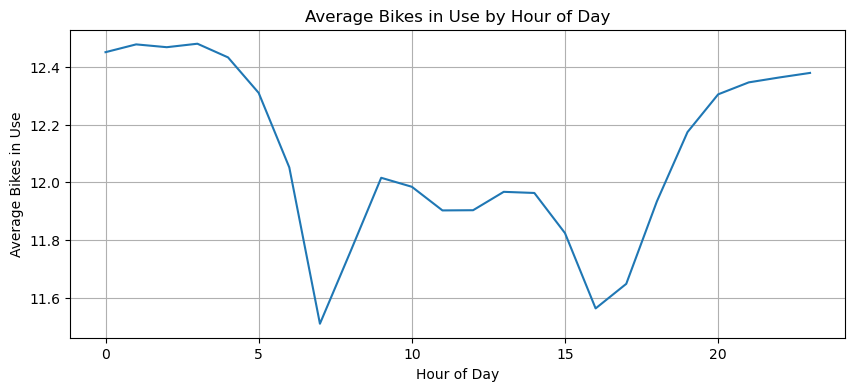

In [36]:
import matplotlib.pyplot as plt

hourly_avg = bikes_weather.groupby('hour')['bikes_in_use'].mean()

plt.figure(figsize=(10,4))
hourly_avg.plot()
plt.title("Average Bikes in Use by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Bikes in Use")
plt.grid(True)
plt.show()


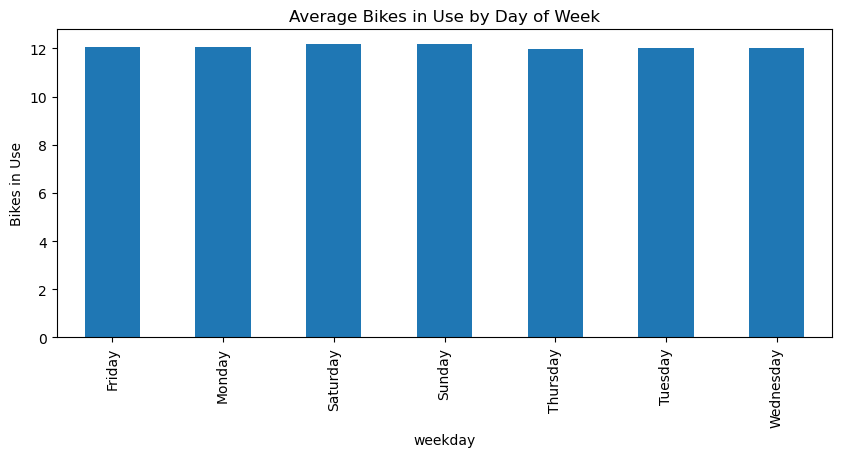

In [37]:
weekday_avg = bikes_weather.groupby('weekday')['bikes_in_use'].mean()

plt.figure(figsize=(10,4))
weekday_avg.plot(kind='bar')
plt.title("Average Bikes in Use by Day of Week")
plt.ylabel("Bikes in Use")
plt.show()


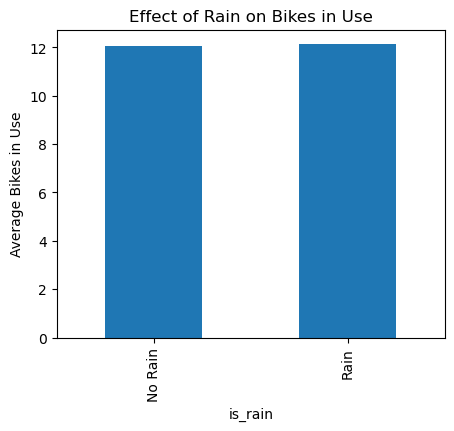

In [38]:
rain_avg = bikes_weather.groupby('is_rain')['bikes_in_use'].mean()

plt.figure(figsize=(5,4))
rain_avg.plot(kind='bar')
plt.title("Effect of Rain on Bikes in Use")
plt.ylabel("Average Bikes in Use")
plt.xticks([0,1], ['No Rain','Rain'])
plt.show()


C:\Users\Rajeshwari\AppData\Local\Temp\ipykernel_7312\356689304.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_avg = bikes_weather.groupby('temp_band')['bikes_in_use'].mean()


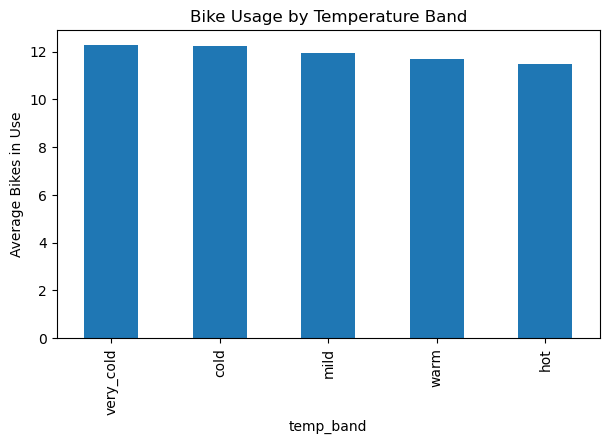

In [39]:
temp_avg = bikes_weather.groupby('temp_band')['bikes_in_use'].mean()

plt.figure(figsize=(7,4))
temp_avg.plot(kind='bar')
plt.title("Bike Usage by Temperature Band")
plt.ylabel("Average Bikes in Use")
plt.show()


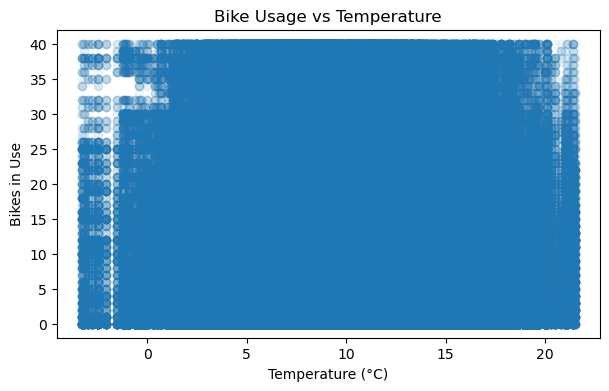

In [40]:
plt.figure(figsize=(7,4))
plt.scatter(bikes_weather['temp'], bikes_weather['bikes_in_use'], alpha=0.05)
plt.title("Bike Usage vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Bikes in Use")
plt.show()


# Feature engineering on bikes_weather

In [41]:
import pandas as pd

bikes_fe = bikes_weather.copy()

bikes_fe['hour_of_day'] = bikes_fe['last_reported'].dt.hour
bikes_fe['weekday'] = bikes_fe['last_reported'].dt.day_name()
bikes_fe['is_weekend'] = bikes_fe['weekday'].isin(['Saturday', 'Sunday'])

# Commute hours: 7-9 and 16-19 on weekdays
bikes_fe['is_commute_hour'] = (
    (~bikes_fe['is_weekend']) &
    (bikes_fe['hour_of_day'].isin([7, 8, 9, 16, 17, 18, 19]))
)

# Rain categories
bikes_fe['rain_band'] = pd.cut(
    bikes_fe['rain'],
    bins=[-0.001, 0, 0.5, 2, 100],
    labels=['no_rain', 'light', 'moderate', 'heavy']
)

# Temperature categories
bikes_fe['temp_band'] = pd.cut(
    bikes_fe['temp'],
    bins=[-50, 5, 10, 15, 20, 50],
    labels=['very_cold', 'cold', 'mild', 'warm', 'hot']
)

bikes_fe[['last_reported', 'hour_of_day', 'weekday',
          'is_weekend', 'is_commute_hour',
          'rain', 'rain_band', 'temp', 'temp_band']].head()


,last_reported,hour_of_day,weekday,is_weekend,is_commute_hour,rain,rain_band,temp,temp_band
7,2025-03-01 01:05:00,1,Saturday,True,False,0.0,no_rain,4.0,very_cold
8,2025-03-01 01:15:00,1,Saturday,True,False,0.0,no_rain,4.0,very_cold
9,2025-03-01 01:25:00,1,Saturday,True,False,0.0,no_rain,4.0,very_cold
10,2025-03-01 01:35:00,1,Saturday,True,False,0.0,no_rain,4.0,very_cold
11,2025-03-01 01:45:00,1,Saturday,True,False,0.0,no_rain,4.0,very_cold


In [42]:
# HOURLY AGGREGATED DATA

bikes_fe['datetime_hour'] = pd.to_datetime(bikes_fe['datetime_hour'])

hourly = (
    bikes_fe
    .groupby('datetime_hour', as_index=False)
    .agg({
        'bikes_in_use': 'sum',
        'rain': 'mean',
        'temp': 'mean',
        'wdsp': 'mean',
        'rhum': 'mean'
    })
)

hourly = hourly.rename(columns={
    'bikes_in_use': 'total_bikes_in_use',
    'rain': 'rain_mm',
    'temp': 'temperature_C',
    'wdsp': 'wind_speed',
    'rhum': 'rel_humidity'
})

hourly['hour_of_day'] = hourly['datetime_hour'].dt.hour
hourly['weekday'] = hourly['datetime_hour'].dt.day_name()
hourly['is_weekend'] = hourly['weekday'].isin(['Saturday', 'Sunday'])
hourly['is_commute_hour'] = (
    (~hourly['is_weekend']) &
    (hourly['hour_of_day'].isin([7, 8, 9, 16, 17, 18, 19]))
)

hourly['rain_band'] = pd.cut(
    hourly['rain_mm'],
    bins=[-0.001, 0, 0.5, 2, 100],
    labels=['no_rain', 'light', 'moderate', 'heavy']
)

hourly['temp_band'] = pd.cut(
    hourly['temperature_C'],
    bins=[-50, 5, 10, 15, 20, 50],
    labels=['very_cold', 'cold', 'mild', 'warm', 'hot']
)

hourly.head()


,datetime_hour,total_bikes_in_use,rain_mm,temperature_C,wind_speed,rel_humidity,hour_of_day,weekday,is_weekend,is_commute_hour,rain_band,temp_band
0,2025-03-01 01:00:00,9273,0.0,4.0,4.0,80.0,1,Saturday,True,False,no_rain,very_cold
1,2025-03-01 02:00:00,8979,0.0,4.2,4.0,75.0,2,Saturday,True,False,no_rain,very_cold
2,2025-03-01 03:00:00,9835,0.0,4.0,4.0,77.0,3,Saturday,True,False,no_rain,very_cold
3,2025-03-01 04:00:00,8928,0.0,2.3,4.0,84.0,4,Saturday,True,False,no_rain,very_cold
4,2025-03-01 05:00:00,10239,0.0,2.8,5.0,82.0,5,Saturday,True,False,no_rain,very_cold


In [46]:

#FINAL ROW-LEVEL DATASET FOR POWER BI

cols_for_pbi = [
    'last_reported',
    'station_id',
    'name',
    'lat',
    'lon',
    'capacity',
    'bikes_in_use',
    'datetime_hour',
    'hour_of_day',
    'weekday',
    'is_weekend',
    'is_commute_hour',
    'rain',
    'temp',
    'wdsp',
    'rhum',
    'rain_band',
    'temp_band'
]

bikes_for_pbi = bikes_fe[cols_for_pbi].copy()

print("Row-level dataset shape:", bikes_for_pbi.shape)
bikes_for_pbi.head()


Row-level dataset shape: (1879621, 18)


,last_reported,station_id,name,lat,lon,capacity,bikes_in_use,datetime_hour,hour_of_day,weekday,is_weekend,is_commute_hour,rain,temp,wdsp,rhum,rain_band,temp_band
7,2025-03-01 01:05:00,104,GRANGEGORMAN LOWER (CENTRAL),53.35517,-6.278424,40,0,2025-03-01 01:00:00,1,Saturday,True,False,0.0,4.0,4.0,80.0,no_rain,very_cold
8,2025-03-01 01:15:00,104,GRANGEGORMAN LOWER (CENTRAL),53.35517,-6.278424,40,0,2025-03-01 01:00:00,1,Saturday,True,False,0.0,4.0,4.0,80.0,no_rain,very_cold
9,2025-03-01 01:25:00,104,GRANGEGORMAN LOWER (CENTRAL),53.35517,-6.278424,40,0,2025-03-01 01:00:00,1,Saturday,True,False,0.0,4.0,4.0,80.0,no_rain,very_cold
10,2025-03-01 01:35:00,104,GRANGEGORMAN LOWER (CENTRAL),53.35517,-6.278424,40,0,2025-03-01 01:00:00,1,Saturday,True,False,0.0,4.0,4.0,80.0,no_rain,very_cold
11,2025-03-01 01:45:00,104,GRANGEGORMAN LOWER (CENTRAL),53.35517,-6.278424,40,0,2025-03-01 01:00:00,1,Saturday,True,False,0.0,4.0,4.0,80.0,no_rain,very_cold


In [47]:
output_path = r"C:\Dublin_Bikes_data\bikes_weather_rowlevel_clean.csv"

bikes_for_pbi.to_csv(output_path, index=False)

print("Saved to:", output_path)


Saved to: C:\Dublin_Bikes_data\bikes_weather_rowlevel_clean.csv
